# 02 · Analisi esplorativa (EDA) — Andora
Trend macro Nord-ovest, quotazioni OMI per stato, distribuzioni e relazioni del micro dataset.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import pandas as pd, numpy as np
pd.set_option('display.width', 120)
import matplotlib.pyplot as plt

In [2]:
from data_fetcher import fetch_istat_ipab, load_omi_b3, simulate_micro_dataset
istat = fetch_istat_ipab(); omi = load_omi_b3(); micro = simulate_micro_dataset(salva=False)

[ISTAT] scaricate 44 osservazioni reali (area=ITC).


## Trend ISTAT Nord-ovest (2015→oggi)
Prezzi piatti/in calo 2015-2019, forte ripresa dal 2020.

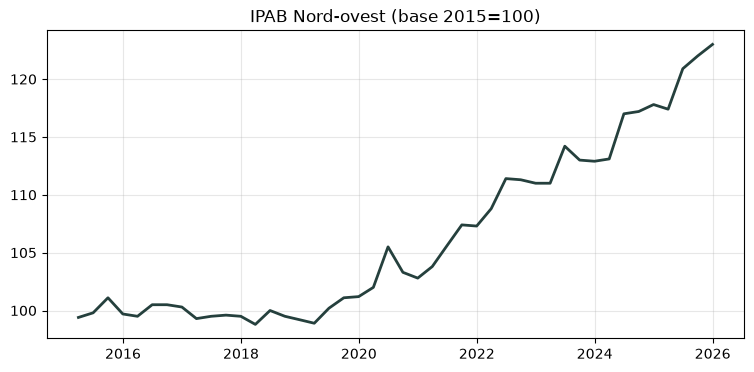

In [3]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(istat['Data'], istat['Indice_Prezzo'], color='#25403D', lw=2)
ax.set_title('IPAB Nord-ovest (base 2015=100)'); ax.grid(alpha=.3); plt.show()

## Quotazioni OMI B3 per stato di conservazione (€/mq)

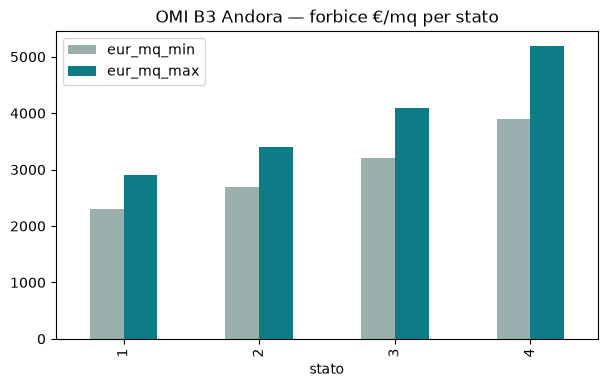

In [4]:
ax = omi.plot(x='stato', y=['eur_mq_min','eur_mq_max'], kind='bar',
              color=['#9AB0AD','#0E7C86'], figsize=(7,4))
ax.set_title('OMI B3 Andora — forbice €/mq per stato'); plt.show()

## Micro dataset — prezzo vs metratura, colore = distanza dal mare

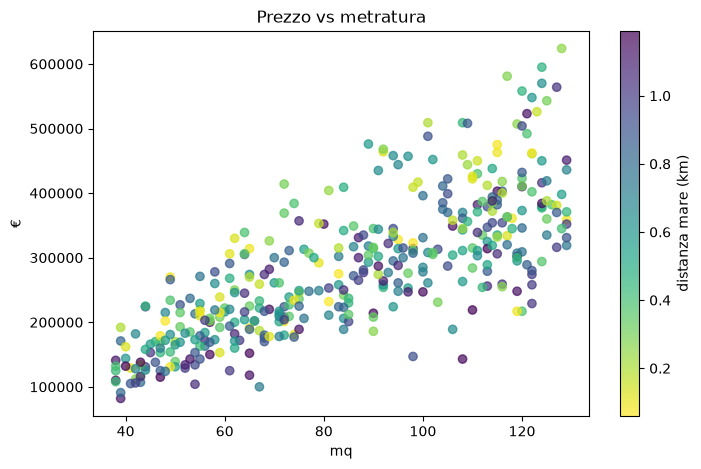

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
sc = ax.scatter(micro['metratura'], micro['prezzo_vendita_eur'],
                c=micro['distanza_mare_km'], cmap='viridis_r', alpha=.7)
plt.colorbar(sc, label='distanza mare (km)'); ax.set_xlabel('mq'); ax.set_ylabel('€')
ax.set_title('Prezzo vs metratura'); plt.show()

## Correlazioni

In [6]:
num = micro.copy()
num['classe_ord'] = num['classe_energetica'].map({'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1})
num = num.drop(columns=['classe_energetica'])
num.corr(numeric_only=True)['prezzo_vendita_eur'].sort_values(ascending=False)

prezzo_vendita_eur     1.000000
metratura              0.768106
stato_conservazione    0.522912
ascensore              0.297520
piano                  0.139006
classe_ord             0.068413
box_auto               0.041011
distanza_mare_km      -0.171195
Name: prezzo_vendita_eur, dtype: float64